# Deviate Analysis Demo

这个 notebook 只读取 `pricing_marl` 内部的数据，默认使用 `pricing_marl/data/result_K30_qtable`。

输出内容只有两类：
1. 每一种 deviation 的汇总打印
2. 每一种 deviation 的双子图

In [1]:
import json
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_pricing_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
        pricing_root = candidate / "pricing_marl"
        if (pricing_root / "src").exists() and (pricing_root / "data").exists():
            return pricing_root.resolve()
    raise FileNotFoundError("Could not find pricing_marl root containing src/ and data/")


PRICING_ROOT = find_pricing_root()

if str(PRICING_ROOT) not in sys.path:
    sys.path.insert(0, str(PRICING_ROOT))

from src.config import Config
from src.environment import compute_nash_and_monopoly_static, get_demand_and_profit_static
from src.strategies import ACT_ABOVE, ACT_MATCH, get_strategy_function, get_strategy_name

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
# Parameters: edit only this cell.
results_dir_name = "result_K30_qtable"
strategy_label = "4strats"   # "3strats" or "4strats"
N = 10
mu = 0.25
K = 30
run_id = 1

seller_id_to_deviate = 0
window_blocks = 5
profit_tolerance = 1e-3

In [3]:
def get_results_root(results_dir_name: str) -> Path:
    results_root = PRICING_ROOT / "data" / results_dir_name
    if not results_root.exists():
        raise FileNotFoundError(results_root)
    return results_root


def load_case(results_dir_name: str, strategy_label: str, N: int, mu: float, K: int, run_id: int):
    results_root = get_results_root(results_dir_name)
    experiment_name = f"scan_{strategy_label}_mu{mu}_k{K}"
    experiment_dir = results_root / experiment_name
    run_dir = experiment_dir / f"N_{N}"

    run_path = run_dir / f"run_{run_id}.parquet"
    qtable_path = run_dir / f"run_{run_id}_qtable.parquet"
    config_path = experiment_dir / f"Config_N_{N}.json"

    for path in [run_path, qtable_path, config_path]:
        if not path.exists():
            raise FileNotFoundError(path)

    config_raw = json.loads(config_path.read_text())
    config_fields = set(Config.__dataclass_fields__.keys())
    path_fields = {"base_dir", "data_dir", "lookup_dir", "results_dir"}
    config_kwargs = {
        key: value
        for key, value in config_raw.items()
        if key in config_fields and key not in path_fields
    }
    config = Config(**config_kwargs)

    run_df = pd.read_parquet(run_path)
    qtable_df = pd.read_parquet(qtable_path)
    return config, run_df, qtable_df, results_root, run_path, qtable_path


def build_price_grid(config: Config):
    p_nash, p_monopoly = compute_nash_and_monopoly_static(
        config.num_sellers,
        config.a_val,
        config.mu,
        config.a0,
        config.c_val,
    )
    step = (p_monopoly - p_nash) / (config.num_grids - 3)
    price_grid = np.linspace(p_nash - step, p_monopoly + step, config.num_grids)
    if price_grid[0] < config.c_val:
        price_grid[0] = config.c_val
    return price_grid


def extract_reference_window(run_df: pd.DataFrame, K: int, window_blocks: int = 5) -> pd.DataFrame:
    window_steps = window_blocks * K
    ref_df = run_df.iloc[-window_steps:].reset_index(drop=True).copy()
    expected = np.tile(np.arange(K), window_blocks)
    actual = ref_df["step_in_k"].to_numpy()
    if not np.array_equal(actual, expected):
        raise ValueError("The last 5K window is not aligned on full K-block boundaries.")
    return ref_df


def nearest_state_idx(price_grid: np.ndarray, price_value: float) -> int:
    return int(np.argmin(np.abs(price_grid - float(price_value))))


def build_q_lookup(qtable_df: pd.DataFrame):
    q_final = qtable_df[qtable_df["qtable_type"] == "final"].copy()
    lookup = {}
    for (seller_id, state_idx), group in q_final.groupby(["seller_id", "state_idx"], sort=True):
        lookup[(int(seller_id), int(state_idx))] = group.sort_values("action_idx").reset_index(drop=True)
    return lookup


def best_action_idx(q_rows: pd.DataFrame) -> int:
    max_q = q_rows["q_value"].max()
    best_rows = q_rows[np.isclose(q_rows["q_value"], max_q)].sort_values("action_idx")
    return int(best_rows.iloc[0]["action_idx"])


def action_profile_for_state(config: Config, q_lookup, state_idx: int, deviator_id: Optional[int] = None, override_action_idx: Optional[int] = None):
    action_indices = []
    for seller_id in range(config.num_sellers):
        q_rows = q_lookup[(seller_id, state_idx)]
        action_idx = best_action_idx(q_rows)
        if deviator_id is not None and seller_id == deviator_id and override_action_idx is not None:
            action_idx = override_action_idx
        action_indices.append(int(action_idx))
    return action_indices


def action_names_from_indices(config: Config, action_indices):
    return [get_strategy_name(config.active_strategies[action_idx]) for action_idx in action_indices]


def simulate_k_block(config: Config, price_grid: np.ndarray, start_state_idx: int, action_indices):
    current_indices = [int(start_state_idx)] * config.num_sellers
    strategy_funcs = [get_strategy_function(config.active_strategies[action_idx]) for action_idx in action_indices]
    rows = []

    for step_in_k in range(config.K):
        prices = np.array([price_grid[idx] for idx in current_indices], dtype=float)
        profits = get_demand_and_profit_static(
            prices,
            config.a_val,
            config.mu,
            config.a0,
            config.c_val,
        )

        row = {
            "step_in_k": step_in_k,
            "price_min": float(prices.min()),
            "price_mean": float(prices.mean()),
            "state_idx_start": int(start_state_idx),
        }
        for seller_id in range(config.num_sellers):
            row[f"a_{seller_id}"] = int(config.active_strategies[action_indices[seller_id]])
            row[f"p_{seller_id}"] = float(prices[seller_id])
            row[f"pi_{seller_id}"] = float(profits[seller_id])
        rows.append(row)

        next_indices = []
        for seller_id, strategy_func in enumerate(strategy_funcs):
            others = current_indices[:seller_id] + current_indices[seller_id + 1:]
            next_idx = strategy_func(current_indices[seller_id], min(others), config.num_grids)
            next_indices.append(int(next_idx))
        current_indices = next_indices

    next_state_idx = int(min(current_indices))
    return pd.DataFrame(rows), next_state_idx


def compare_profit(dev_profit: float, baseline_profit: float, tol: float) -> str:
    diff = dev_profit - baseline_profit
    if abs(diff) < tol:
        return "same"
    return "higher" if diff > 0 else "lower"


def validate_scenario(config: Config, price_grid: np.ndarray, scenario: dict):
    deviation_4k_df = scenario["deviation_4k_df"]
    first_block_df = deviation_4k_df.iloc[: config.K]
    pre_price = scenario["pre_deviation_price"]

    if not np.isclose(first_block_df.iloc[0]["price_min"], pre_price):
        raise AssertionError("Deviation block does not start from the expected pre-deviation state.")

    top_grid_saturated = scenario["pre_deviation_state_idx"] == config.num_grids - 1
    deviation_action_id = scenario["deviation_action_id"]
    if top_grid_saturated and deviation_action_id in {ACT_MATCH, ACT_ABOVE}:
        expected_price = float(price_grid[-1])
        for seller_id in range(config.num_sellers):
            if not np.isclose(first_block_df[f"p_{seller_id}"], expected_price).all():
                raise AssertionError("Top-grid saturated case with Match/Above should remain at the top grid.")


def summarize_scenario(config: Config, reference_df: pd.DataFrame, scenario: dict, seller_id_to_deviate: int, tol: float):
    pre_state_idx = scenario["pre_deviation_state_idx"]
    pre_price = scenario["pre_deviation_price"]
    dev_df = scenario["deviation_4k_df"]
    seller_profit_col = f"pi_{seller_id_to_deviate}"

    state_returned_anytime = bool(np.isclose(dev_df["price_min"].to_numpy(), pre_price).any())
    state_never_left = bool(np.isclose(dev_df["price_min"].to_numpy(), pre_price).all())

    return_block_offset = None
    if state_never_left:
        return_episodes = 0
        return_k_periods = 0
        profit_horizon_steps = 0
    else:
        for block in scenario["block_diagnostics"][1:]:
            if block["start_state_idx"] == pre_state_idx:
                return_block_offset = int(block["block_offset"])
                break

        if return_block_offset is None:
            return_episodes = None
            return_k_periods = None
            profit_horizon_steps = len(dev_df)
        else:
            return_episodes = return_block_offset - 1
            return_k_periods = return_block_offset - 1
            profit_horizon_steps = return_k_periods * config.K

    deviation_profit = float(dev_df.iloc[:profit_horizon_steps][seller_profit_col].sum()) if profit_horizon_steps > 0 else 0.0
    baseline_profit = float(reference_df.iloc[config.K : config.K + profit_horizon_steps][seller_profit_col].sum()) if profit_horizon_steps > 0 else 0.0
    profit_result = compare_profit(deviation_profit, baseline_profit, tol)

    return {
        "state_returned_anytime": state_returned_anytime,
        "state_never_left": state_never_left,
        "return_episodes": return_episodes,
        "return_k_periods": return_k_periods,
        "profit_horizon_steps": profit_horizon_steps,
        "deviation_profit": deviation_profit,
        "baseline_profit": baseline_profit,
        "profit_result": profit_result,
    }


def run_deviation_scenarios(config: Config, price_grid: np.ndarray, reference_df: pd.DataFrame, q_lookup, seller_id_to_deviate: int = 0):
    start_of_second_block = reference_df.loc[config.K, "price_min"]
    pre_deviation_state_idx = nearest_state_idx(price_grid, start_of_second_block)
    pre_deviation_price = float(price_grid[pre_deviation_state_idx])

    original_action_indices = action_profile_for_state(config, q_lookup, pre_deviation_state_idx)
    seller_q_rows = q_lookup[(seller_id_to_deviate, pre_deviation_state_idx)]
    best_idx = best_action_idx(seller_q_rows)
    deviation_action_indices = [action_idx for action_idx in range(config.num_actions) if action_idx != best_idx]

    scenarios = []
    for deviation_action_idx in deviation_action_indices:
        current_state_idx = pre_deviation_state_idx
        deviated_blocks = []
        block_diagnostics = []

        for block_offset in range(4):
            chosen_actions = action_profile_for_state(
                config,
                q_lookup,
                current_state_idx,
                deviator_id=seller_id_to_deviate if block_offset == 0 else None,
                override_action_idx=deviation_action_idx if block_offset == 0 else None,
            )

            block_df, next_state_idx = simulate_k_block(
                config=config,
                price_grid=price_grid,
                start_state_idx=current_state_idx,
                action_indices=chosen_actions,
            )
            block_df["block_offset"] = block_offset + 1
            deviated_blocks.append(block_df)

            block_diagnostics.append(
                {
                    "block_offset": block_offset + 1,
                    "start_state_idx": int(current_state_idx),
                    "start_price": float(price_grid[current_state_idx]),
                    "action_indices": [int(x) for x in chosen_actions],
                    "action_names": action_names_from_indices(config, chosen_actions),
                    "next_state_idx": int(next_state_idx),
                    "next_state_price": float(price_grid[next_state_idx]),
                }
            )
            current_state_idx = next_state_idx

        deviation_4k_df = pd.concat(deviated_blocks, ignore_index=True)
        deviation_5k_df = pd.concat([reference_df.iloc[: config.K].copy(), deviation_4k_df], ignore_index=True)
        deviation_5k_df["t_local"] = np.arange(len(deviation_5k_df))

        scenario = {
            "deviation_action_idx": int(deviation_action_idx),
            "deviation_action_id": int(config.active_strategies[deviation_action_idx]),
            "deviation_action_name": get_strategy_name(config.active_strategies[deviation_action_idx]),
            "best_action_idx": int(best_idx),
            "best_action_id": int(config.active_strategies[best_idx]),
            "best_action_name": get_strategy_name(config.active_strategies[best_idx]),
            "pre_deviation_state_idx": int(pre_deviation_state_idx),
            "pre_deviation_price": pre_deviation_price,
            "original_action_indices": [int(x) for x in original_action_indices],
            "original_action_names": action_names_from_indices(config, original_action_indices),
            "block_diagnostics": block_diagnostics,
            "deviation_4k_df": deviation_4k_df,
            "deviation_5k_df": deviation_5k_df,
        }
        validate_scenario(config, price_grid, scenario)
        scenarios.append(scenario)

    return scenarios


def print_scenario_summary(config: Config, scenario: dict, summary: dict, seller_id_to_deviate: int, tol: float):
    action_text = ", ".join(
        f"seller {seller_id}: {action_name}"
        for seller_id, action_name in enumerate(scenario["original_action_names"])
    )

    print("=" * 100)
    print(f"Deviation: seller {seller_id_to_deviate} | {scenario['best_action_name']} -> {scenario['deviation_action_name']}")
    print(f"0. Injection state: grid {scenario['pre_deviation_state_idx']} | price {scenario['pre_deviation_price']:.6f}")
    print(f"   Actions at this state: {action_text}")
    print(f"   Deviator: seller {seller_id_to_deviate} | deviated action: {scenario['deviation_action_name']}")
    print(f"1. State returned within the post-deviation 4K horizon: {summary['state_returned_anytime']}")

    if summary['state_never_left']:
        print("2. The state never left the injection state. Return time = 0 episodes = 0 K periods.")
    elif summary['return_episodes'] is None:
        print("2. The state did not return to the injection state on any later episode start within 4K.")
        print("   Episode-start return time: not returned within 4 episodes")
        print("   K-period return time: not returned within 4 K periods")
    else:
        print(f"2. Episode-start return time: {summary['return_episodes']} episodes")
        print(f"   K-period return time: {summary['return_k_periods']} K periods")

    print(f"3. Seller {seller_id_to_deviate} profit from deviation start to the return horizon: {summary['deviation_profit']:.6f}")
    print(f"4. Baseline run profit on the same horizon: {summary['baseline_profit']:.6f}")
    print(f"   Profit comparison with tolerance {tol:.0e}: {summary['profit_result']}")


def plot_price_panel(ax, df: pd.DataFrame, config: Config, title: str):
    colors = plt.cm.tab10(np.linspace(0, 1, config.num_sellers))
    for seller_id in range(config.num_sellers):
        ax.step(
            df["t_local"],
            df[f"p_{seller_id}"],
            where="post",
            linewidth=1.2,
            color=colors[seller_id % len(colors)],
            alpha=0.75,
            label=f"seller {seller_id}",
        )
    ax.step(df["t_local"], df["price_min"], where="post", color="black", linewidth=2.4, label="price_min")
    ax.axvline(config.K, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Atomic step inside 5K window")
    ax.set_ylabel("Price")


In [4]:
config, run_df, qtable_df, results_root, run_path, qtable_path = load_case(
    results_dir_name=results_dir_name,
    strategy_label=strategy_label,
    N=N,
    mu=mu,
    K=K,
    run_id=run_id,
)

price_grid = build_price_grid(config)
reference_df = extract_reference_window(run_df, K=config.K, window_blocks=window_blocks)
reference_df["t_local"] = np.arange(len(reference_df))
q_lookup = build_q_lookup(qtable_df)

scenarios = run_deviation_scenarios(
    config=config,
    price_grid=price_grid,
    reference_df=reference_df,
    q_lookup=q_lookup,
    seller_id_to_deviate=seller_id_to_deviate,
)

scenario_summaries = [
    summarize_scenario(
        config=config,
        reference_df=reference_df,
        scenario=scenario,
        seller_id_to_deviate=seller_id_to_deviate,
        tol=profit_tolerance,
    )
    for scenario in scenarios
]


In [5]:
for scenario, summary in zip(scenarios, scenario_summaries):
    print_scenario_summary(
        config=config,
        scenario=scenario,
        summary=summary,
        seller_id_to_deviate=seller_id_to_deviate,
        tol=profit_tolerance,
    )


Deviation: seller 0 | Match -> Undercut
0. Injection state: grid 9 | price 2.369814
   Actions at this state: seller 0: Match, seller 1: Above, seller 2: Above, seller 3: Above, seller 4: Match, seller 5: Match, seller 6: Match, seller 7: Above, seller 8: Above, seller 9: Above
   Deviator: seller 0 | deviated action: Undercut
1. State returned within the post-deviation 4K horizon: True
2. Episode-start return time: 2 episodes
   K-period return time: 2 K periods
3. Seller 0 profit from deviation start to the return horizon: 4.667477
4. Baseline run profit on the same horizon: 5.711653
   Profit comparison with tolerance 1e-03: lower
Deviation: seller 0 | Match -> Above
0. Injection state: grid 9 | price 2.369814
   Actions at this state: seller 0: Match, seller 1: Above, seller 2: Above, seller 3: Above, seller 4: Match, seller 5: Match, seller 6: Match, seller 7: Above, seller 8: Above, seller 9: Above
   Deviator: seller 0 | deviated action: Above
1. State returned within the post-d

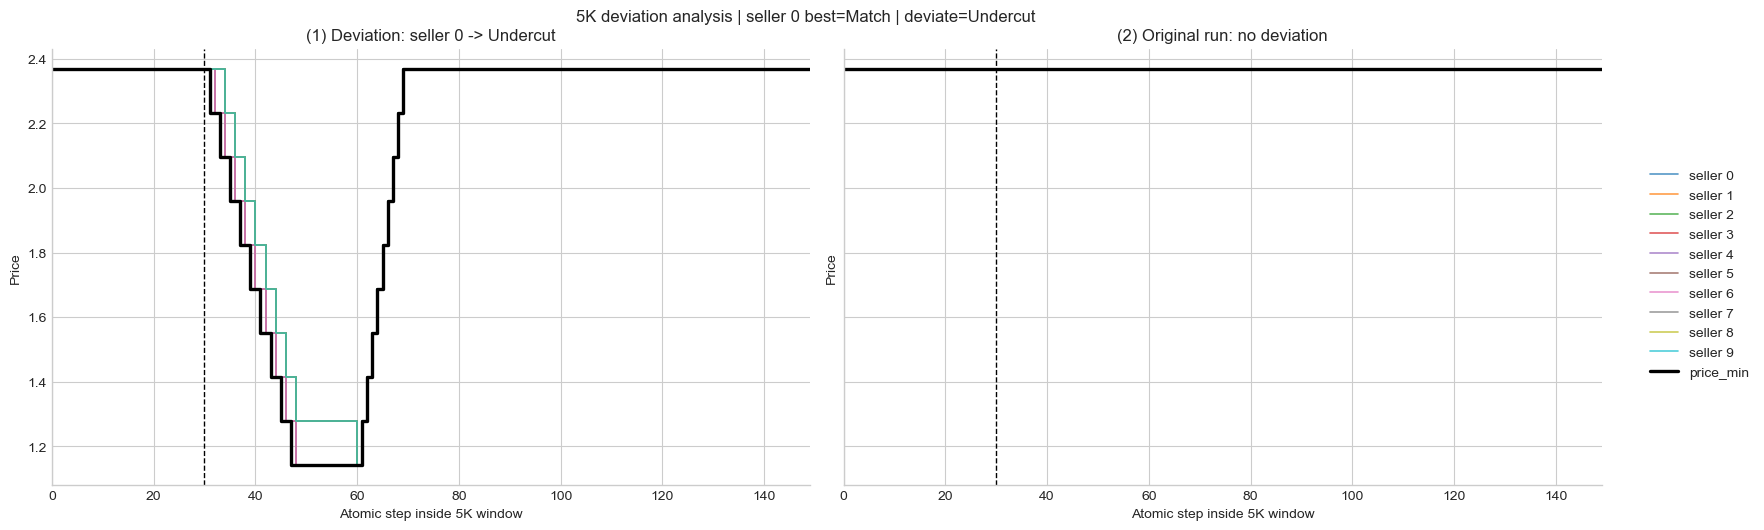

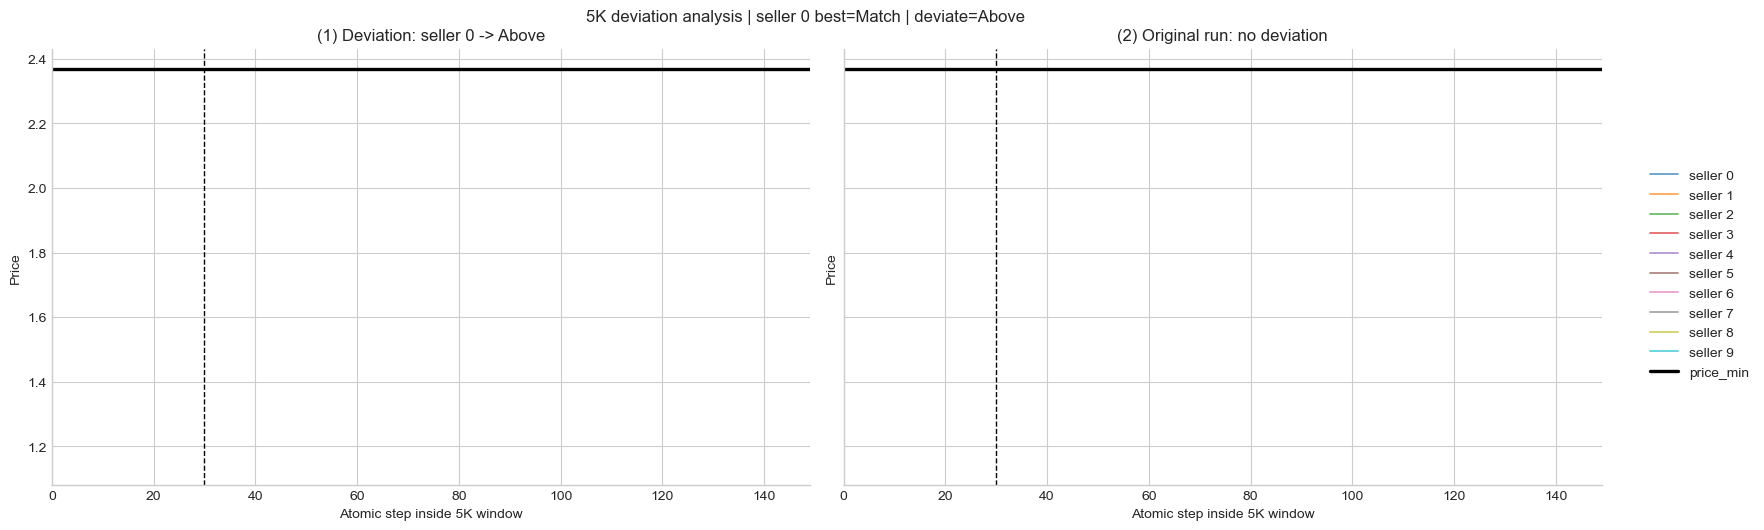

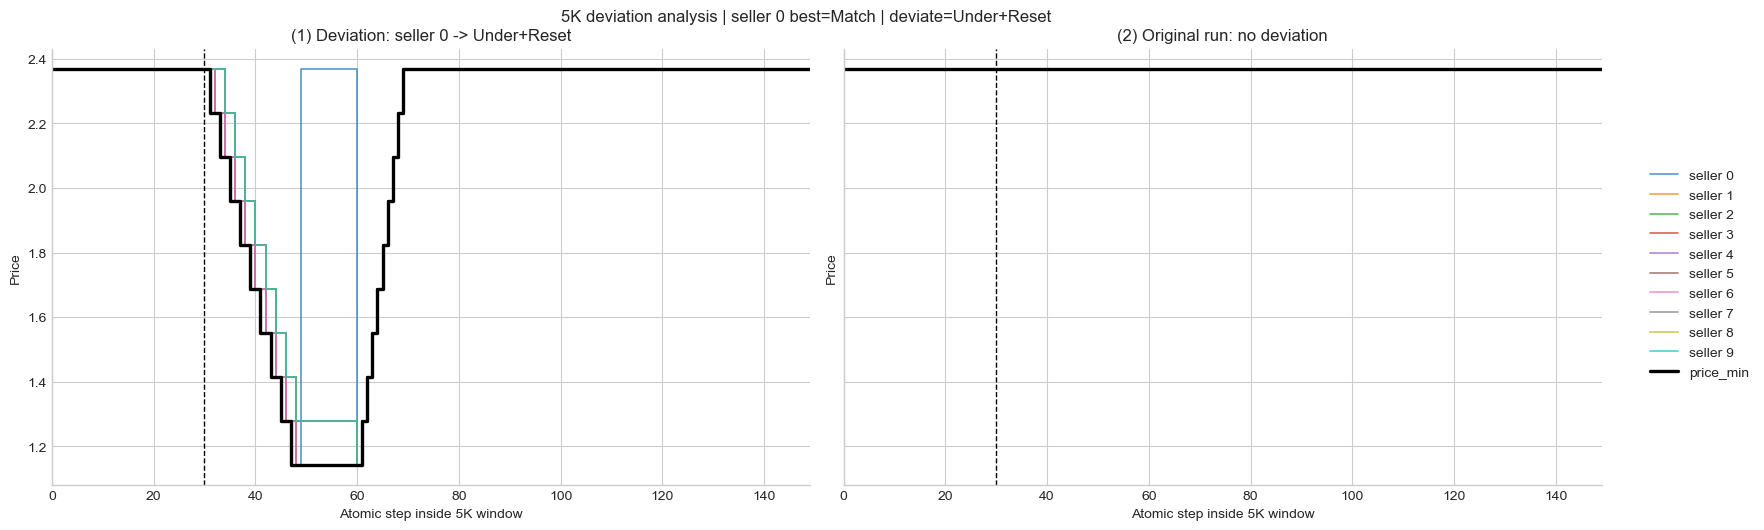

In [6]:
seller_price_cols = [f"p_{seller_id}" for seller_id in range(config.num_sellers)]
all_prices = [reference_df[seller_price_cols].to_numpy().ravel()]
for scenario in scenarios:
    all_prices.append(scenario["deviation_5k_df"][seller_price_cols].to_numpy().ravel())
all_prices = np.concatenate(all_prices)

y_span = float(all_prices.max() - all_prices.min())
y_pad = 0.05 * y_span if y_span > 0 else 0.05
shared_xlim = (0, len(reference_df) - 1)
shared_ylim = (float(all_prices.min() - y_pad), float(all_prices.max() + y_pad))

for scenario in scenarios:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True, constrained_layout=True)

    plot_price_panel(
        axes[0],
        scenario["deviation_5k_df"],
        config,
        title=f"(1) Deviation: seller 0 -> {scenario['deviation_action_name']}",
    )
    plot_price_panel(
        axes[1],
        reference_df,
        config,
        title="(2) Original run: no deviation",
    )

    for ax in axes:
        ax.set_xlim(*shared_xlim)
        ax.set_ylim(*shared_ylim)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle(
        (
            f"5K deviation analysis | seller 0 best={scenario['best_action_name']} | "
            f"deviate={scenario['deviation_action_name']}"
        ),
        y=1.03,
    )
    plt.show()
